# 05 – Evaluation and Error Analysis

Comprehensive test-set evaluation across all 8 baselines and machine learning models, train-test gap diagnostics, professional blue/white confusion matrices, ROC/PR curves, and failure mode error analysis.

**Author:** Ummay Maimona Chaman (22301719)  
**Course:** CSE437 Data Science — Individual Project

Produces: `models/test_metrics.csv`, `models/test_metrics.json`, `figures/confusion_matrices.png`, `figures/pr_roc_curves.png`, `figures/test_evaluation.png`, `figures/error_analysis.png`, `figures/train_test_gap.png`


## 0 · Environment Setup & Colab Dependencies


In [1]:
%pip install -q "pandas>=2.0" "numpy>=1.24" "matplotlib>=3.7" "seaborn>=0.12" "scikit-learn>=1.3" "joblib>=1.3" "jupyter>=1.0" "scipy>=1.10"


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
import os
import json
import time
import math
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Scikit-learn imports
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, ParameterGrid
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay
)
import joblib

warnings.filterwarnings('ignore')
%matplotlib inline

# Aesthetic styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Dynamic repository root detection (seamless in Colab and local Jupyter)
ROOT = Path.cwd().resolve()
for _candidate in [ROOT, *ROOT.parents]:
    if (_candidate / 'data').exists() and (_candidate / 'notebooks').exists():
        ROOT = _candidate
        break

FIGURES   = ROOT / 'figures'
PROCESSED = ROOT / 'data' / 'processed'
MODELS    = ROOT / 'models'
FIGURES.mkdir(exist_ok=True)
PROCESSED.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)

print('Environment configured successfully. All libraries loaded.')
print(f'Working directory: {ROOT.name if ROOT.name else "."}')


Environment configured successfully. All libraries loaded.
Working directory: cse437-japan-earthquake-occurrence-forecasting-ummay-maimona-chaman


## 1 · Load Models & Test Partition


In [3]:
# Baseline class definitions for unpickling
class GridProbabilityBaseline:
    def __init__(self, grid_probabilities, grid_columns, probability_from_rate=False):
        self.grid_probabilities = grid_probabilities
        self.grid_columns = grid_columns
        self.probability_from_rate = probability_from_rate
    def fit(self, X, y):
        self.classes_ = np.array([0, 1])
        self.default_probability_ = float(np.mean(y))
        return self
    def predict_proba(self, X):
        grid_labels_by_col = {col: col.replace('grid_', '') for col in self.grid_columns}
        active_col = X[self.grid_columns].idxmax(axis=1)
        labels = active_col.map(grid_labels_by_col)
        values = labels.map(self.grid_probabilities).fillna(self.default_probability_).astype(float).to_numpy()
        if self.probability_from_rate:
            values = 1.0 - np.exp(-values * 14.0)
        values = np.clip(values, 0.0, 1.0)
        return np.column_stack([1.0 - values, values])
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

class PersistenceBaseline:
    def fit(self, X, y):
        self.classes_ = np.array([0, 1])
        self.active_risk_ = float(np.mean(y[X['recent_m45_30d'].to_numpy() == 1])) if (X['recent_m45_30d'] == 1).any() else float(np.mean(y))
        self.quiet_risk_ = float(np.mean(y[X['recent_m45_30d'].to_numpy() == 0])) if (X['recent_m45_30d'] == 0).any() else float(np.mean(y))
        return self
    def predict_proba(self, X):
        p = np.where(X['recent_m45_30d'].to_numpy() == 1, self.active_risk_, self.quiet_risk_)
        return np.column_stack([1.0 - p, p])
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

bundle = joblib.load(MODELS / 'forecast_models.joblib')
baselines = bundle['baselines']
models = bundle['models']
scaler = bundle['scaler']
continuous_cols = bundle['continuous_cols']
feature_set = bundle['feature_set']

df_features = pd.read_csv(PROCESSED / 'model_features.csv', parse_dates=['timestamp'])
df_features[bundle['grid_cols']] = df_features[bundle['grid_cols']].astype(float)
unique_timestamps = np.sort(df_features['timestamp'].unique())
test_start_time = unique_timestamps[int(len(unique_timestamps) * 0.85)]
test_mask = df_features['timestamp'] >= test_start_time
train_end_time = unique_timestamps[int(len(unique_timestamps) * 0.70) - 1]
train_mask = df_features['timestamp'] <= train_end_time

X_train = df_features.loc[train_mask, feature_set].copy()
y_train = df_features.loc[train_mask, 'target_m5_14d'].values.astype(int)
X_test  = df_features.loc[test_mask, feature_set].copy()
y_test  = df_features.loc[test_mask, 'target_m5_14d'].values.astype(int)

X_train.loc[:, continuous_cols] = scaler.transform(X_train[continuous_cols])
X_test.loc[:, continuous_cols]  = scaler.transform(X_test[continuous_cols])

print(f'Test Partition: {len(X_test)} samples | Positive Rate: {y_test.mean()*100:.2f}% (No-Skill Baseline)')


Test Partition: 270 samples | Positive Rate: 23.33% (No-Skill Baseline)


## 2 · Comprehensive Result Summary Table


In [4]:
all_evaluated = {**baselines, **models}
results_list = []

for name, clf in all_evaluated.items():
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    pr_auc = average_precision_score(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob) if len(np.unique(y_prob)) > 1 else 0.50
    brier = brier_score_loss(y_test, y_prob)
    
    results_list.append({
        'Model': name,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc,
        'Brier Score': brier,
        'F1-Score': f1,
        'Precision': prec,
        'Recall': rec,
        'Accuracy': acc,
        'Balanced Acc': bal_acc
    })

summary_table = pd.DataFrame(results_list).sort_values('PR-AUC', ascending=False).reset_index(drop=True)
print('=' * 100)
print('                      COMPREHENSIVE TEST EVALUATION SUMMARY TABLE')
print('=' * 100)
display(summary_table.round(3))

summary_table.to_csv(MODELS / 'test_metrics.csv', index=False)
(MODELS / 'test_metrics.json').write_text(json.dumps(summary_table.to_dict(orient='records'), indent=2))


                      COMPREHENSIVE TEST EVALUATION SUMMARY TABLE


,Model,PR-AUC,ROC-AUC,Brier Score,F1-Score,Precision,Recall,Accuracy,Balanced Acc
0,1. Logistic Regression (L2),0.449,0.719,0.216,0.490,0.361,0.762,0.630,0.676
1,2. Random Forest Classifier,0.435,0.709,0.211,0.500,0.368,0.778,0.637,0.686
2,3. Gradient Boosted Trees,0.416,0.682,0.166,0.238,0.476,0.159,0.763,0.553
3,3. Gradient Boosted Trees (Tuned),0.391,0.680,0.166,0.192,0.700,0.111,0.781,0.548
4,4. Multi-Layer Perceptron (MLP),0.382,0.679,0.171,0.265,0.550,0.175,0.774,0.566
5,4. Poisson Seismicity Rate,0.366,0.712,0.222,0.315,0.378,0.270,0.726,0.567
6,2. Historical Grid Base Rate,0.366,0.712,0.165,0.315,0.378,0.270,0.726,0.567
7,1. Dummy Baseline (Global Prior),0.233,0.500,0.179,0.000,0.000,0.000,0.767,0.500
8,3. Persistence (Recent M4.5+),0.233,0.500,0.179,0.000,0.000,0.000,0.767,0.500


2916

## 3 · Train vs Test Generalization Gap Diagnostic


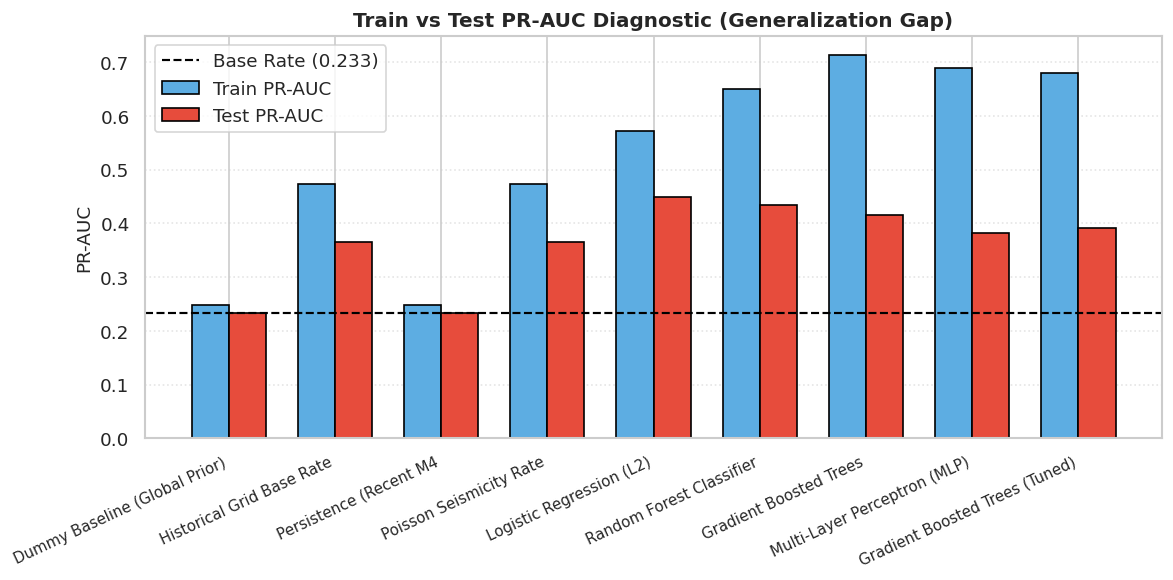

In [5]:
# Overfitting / Underfitting Check
diag_rows = []
for name, clf in all_evaluated.items():
    tr_prob = clf.predict_proba(X_train)[:, 1]
    te_prob = clf.predict_proba(X_test)[:, 1]
    tr_pr = average_precision_score(y_train, tr_prob)
    te_pr = average_precision_score(y_test, te_prob)
    diag_rows.append({'Model': name, 'Train PR-AUC': tr_pr, 'Test PR-AUC': te_pr, 'Gap': tr_pr - te_pr})

diag_df = pd.DataFrame(diag_rows)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(diag_df))
width = 0.35
ax.bar(x - width/2, diag_df['Train PR-AUC'], width, label='Train PR-AUC', color='#5dade2', edgecolor='black')
ax.bar(x + width/2, diag_df['Test PR-AUC'], width, label='Test PR-AUC', color='#e74c3c', edgecolor='black')
ax.axhline(y_test.mean(), color='black', linestyle='--', linewidth=1.3, label=f'Base Rate ({y_test.mean():.3f})')
ax.set_xticks(x)
ax.set_xticklabels([m.split('.')[1].strip() if '.' in m else m for m in diag_df['Model']], rotation=25, ha='right', fontsize=9)
ax.set_ylabel('PR-AUC', fontsize=11); ax.set_title('Train vs Test PR-AUC Diagnostic (Generalization Gap)', fontweight='bold')
ax.legend(); ax.grid(True, axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES / 'train_test_gap.png', dpi=160, bbox_inches='tight')
plt.show()


## 4 · Subplot Confusion Matrices (Professional Blue & White)


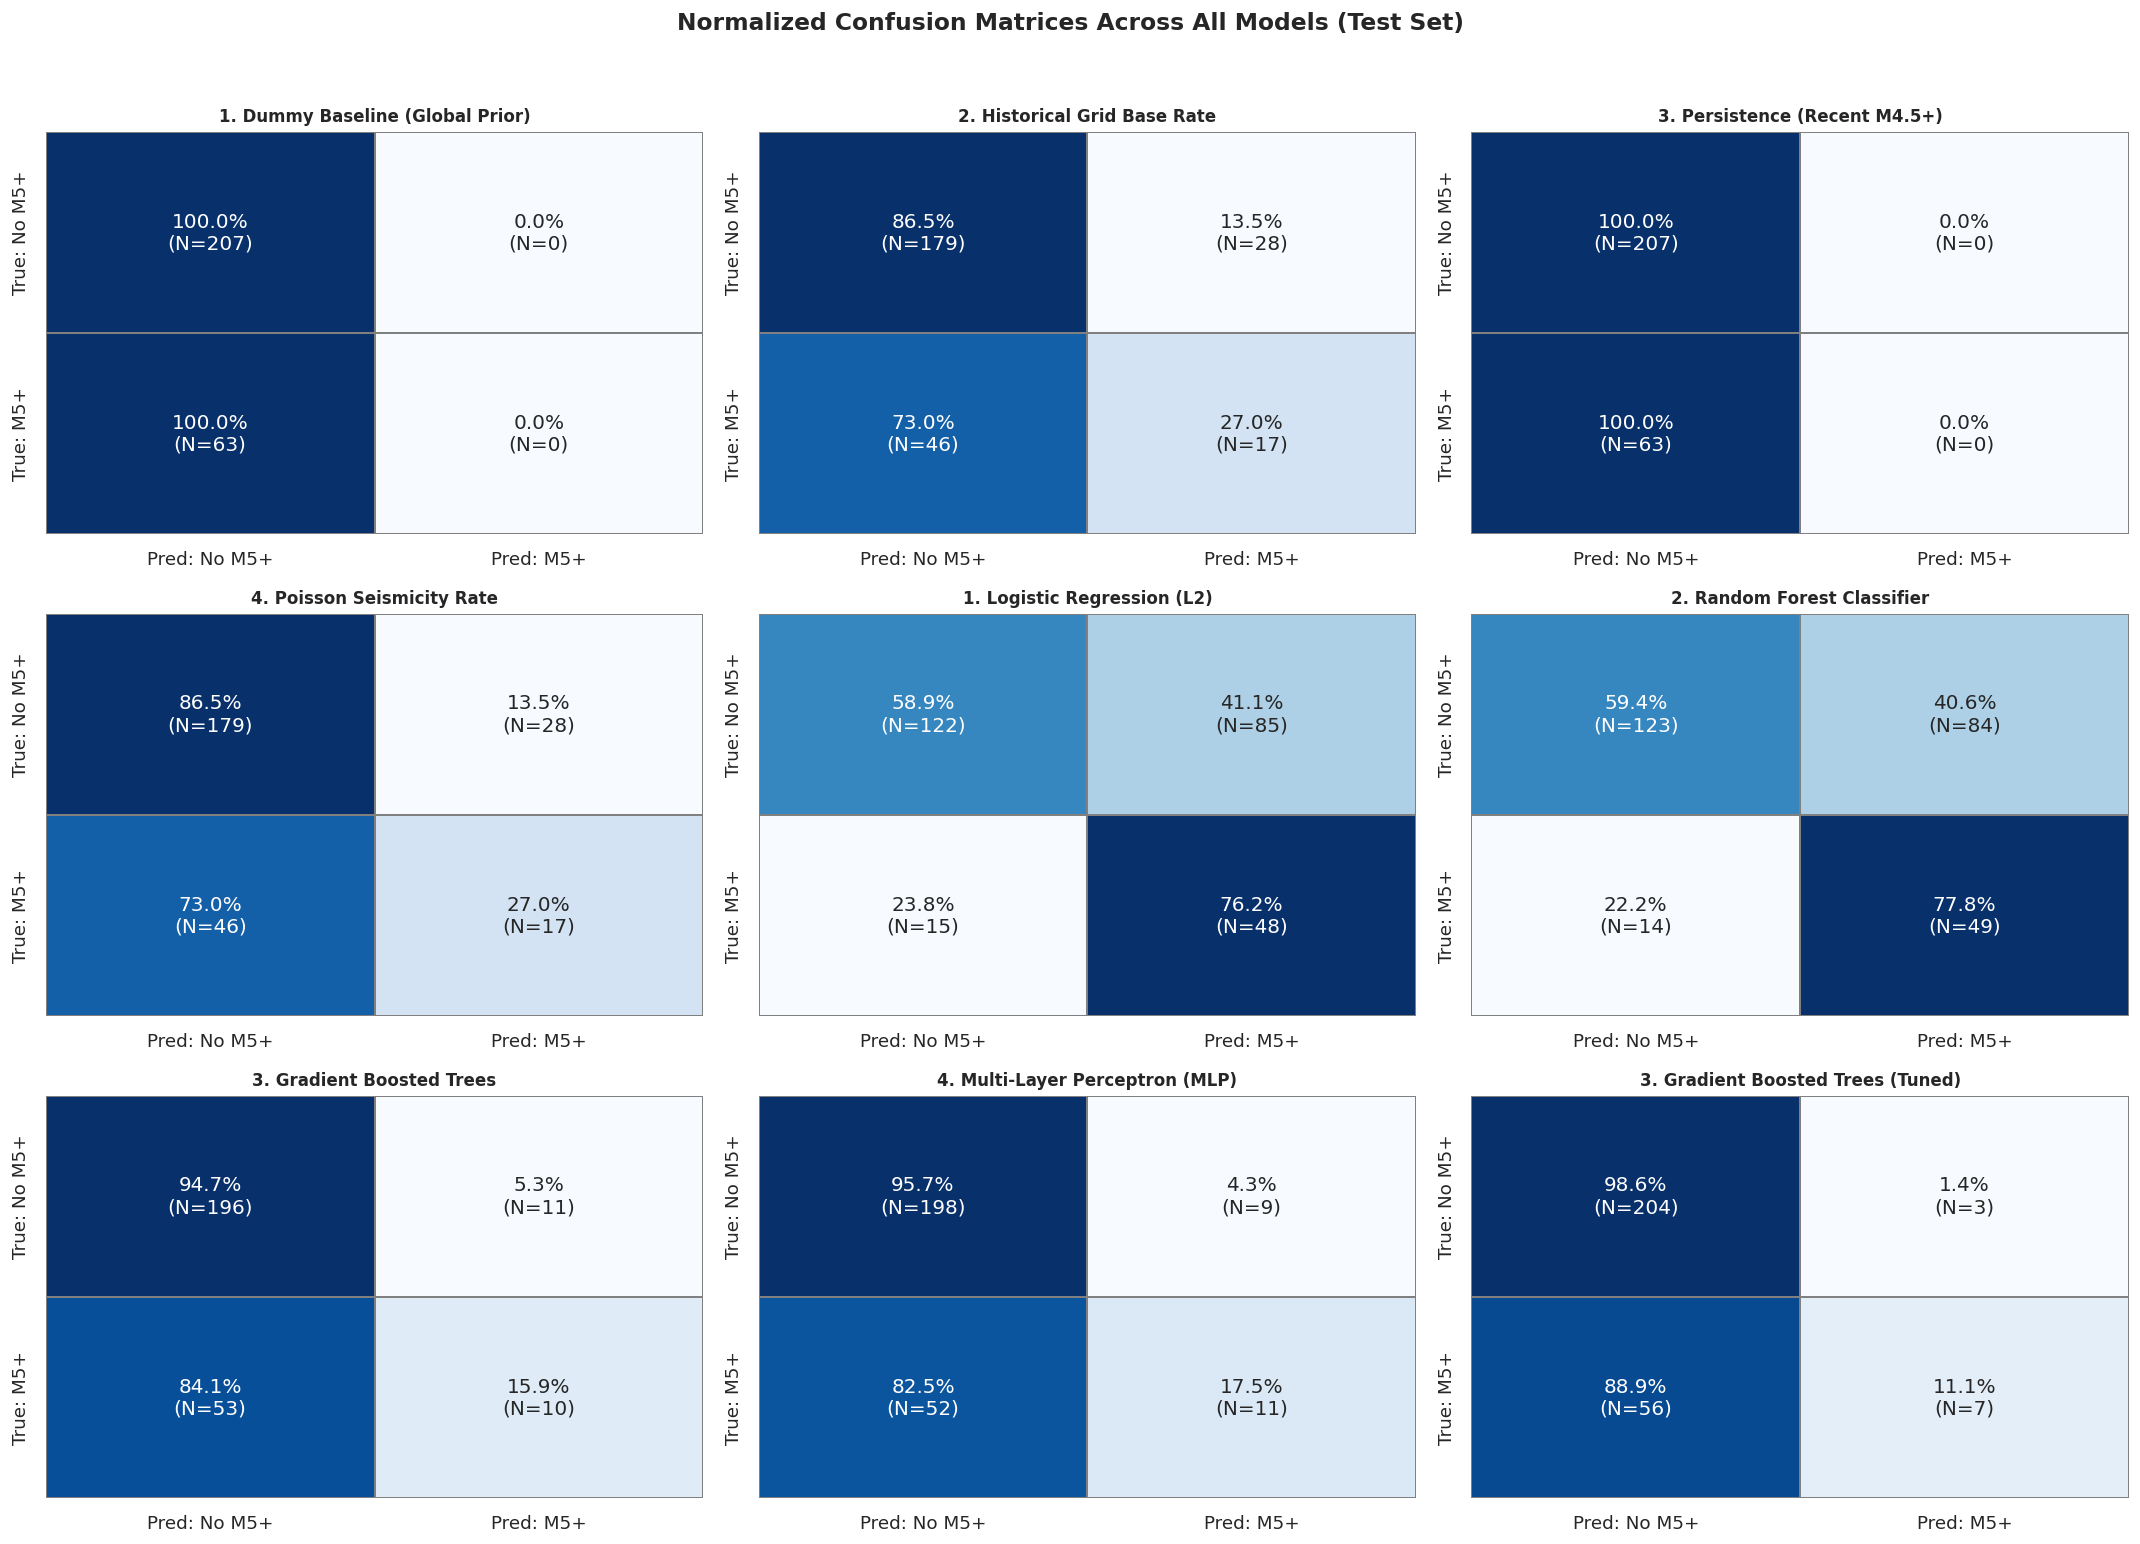

In [6]:
# Confusion Matrices with professional Blue and White colormap (cmap='Blues')
model_keys = list(all_evaluated.keys())
n_models = len(model_keys)
n_cols = 3
n_rows = math.ceil(n_models / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.2 * n_rows))
axes = axes.flatten()

for idx, name in enumerate(model_keys):
    clf = all_evaluated[name]
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, normalize='true') * 100
    cm_counts = confusion_matrix(y_test, y_pred)
    
    annot = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f'{cm[i, j]:.1f}%\n(N={cm_counts[i, j]})'
            
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False, ax=axes[idx],
                xticklabels=['Pred: No M5+', 'Pred: M5+'],
                yticklabels=['True: No M5+', 'True: M5+'],
                linewidths=1.2, linecolor='gray')
    axes[idx].set_title(name, fontsize=10, fontweight='bold')

for ax in axes[n_models:]:
    ax.axis('off')

plt.suptitle('Normalized Confusion Matrices Across All Models (Test Set)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / 'confusion_matrices.png', dpi=160, bbox_inches='tight')
plt.show()


## 5 · Precision-Recall & ROC Curve Subplots


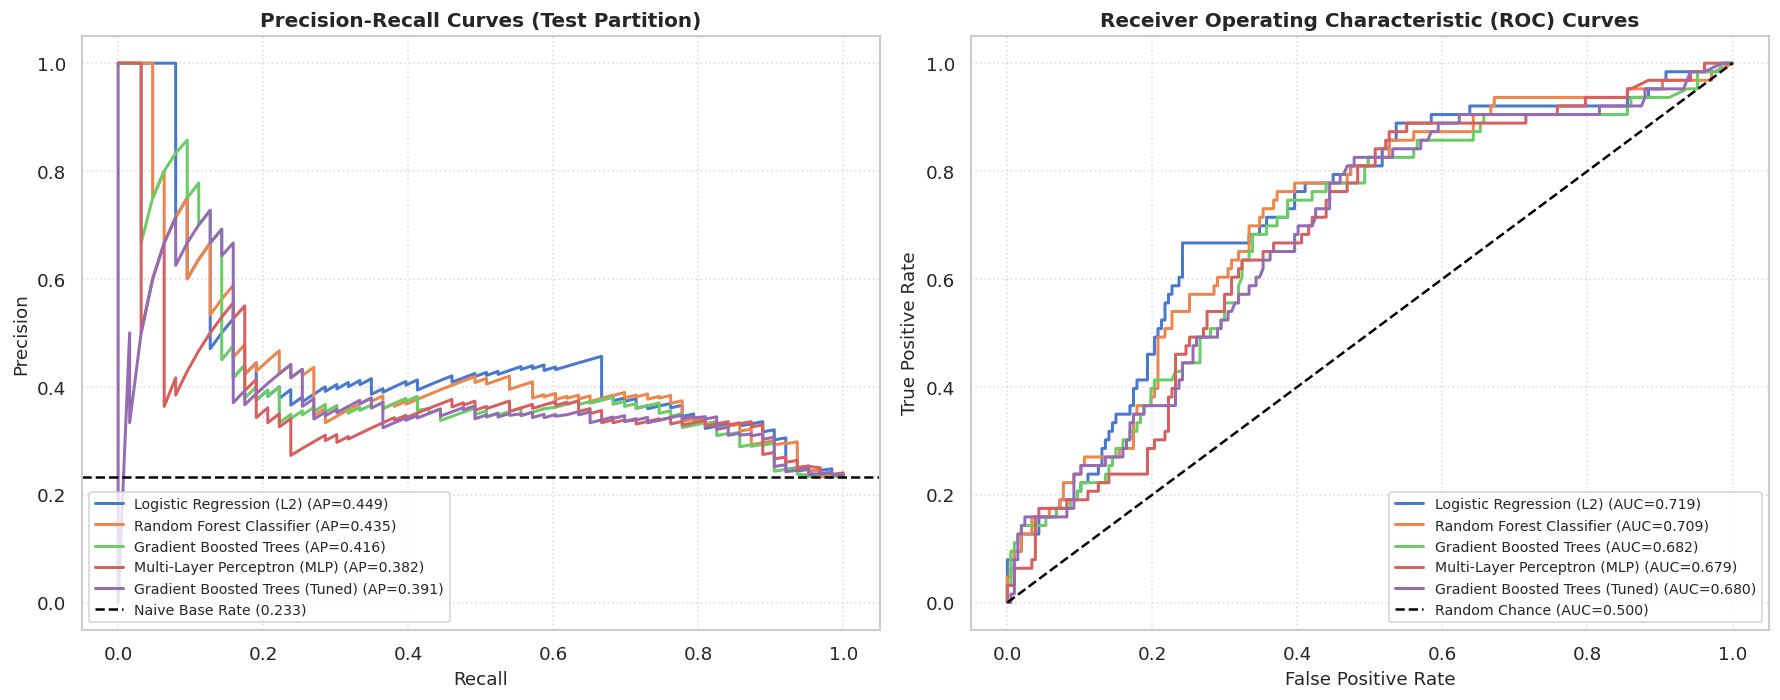

In [7]:
# Precision-Recall and ROC Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
test_base_rate = float(y_test.mean())

for name, clf in models.items():
    y_prob = clf.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    pr_auc_val = average_precision_score(y_test, y_prob)
    ax1.plot(rec, prec, label=f'{name.split(".")[1].strip()} (AP={pr_auc_val:.3f})', linewidth=1.8)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_val = roc_auc_score(y_test, y_prob)
    ax2.plot(fpr, tpr, label=f'{name.split(".")[1].strip()} (AUC={roc_val:.3f})', linewidth=1.8)

ax1.axhline(test_base_rate, color='black', linestyle='--', linewidth=1.5, label=f'Naive Base Rate ({test_base_rate:.3f})')
ax1.set_title('Precision-Recall Curves (Test Partition)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Recall', fontsize=11); ax1.set_ylabel('Precision', fontsize=11)
ax1.legend(loc='lower left', fontsize=8.5); ax1.grid(True, linestyle=':', alpha=0.6)

ax2.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1.5, label='Random Chance (AUC=0.500)')
ax2.set_title('Receiver Operating Characteristic (ROC) Curves', fontsize=12, fontweight='bold')
ax2.set_xlabel('False Positive Rate', fontsize=11); ax2.set_ylabel('True Positive Rate', fontsize=11)
ax2.legend(loc='lower right', fontsize=8.5); ax2.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig(FIGURES / 'pr_roc_curves.png', dpi=160, bbox_inches='tight')
plt.savefig(FIGURES / 'test_evaluation.png', dpi=160, bbox_inches='tight')
plt.show()


## 6 · In-Depth Error Analysis & Failure Mode Diagnostics


Top-Performing Model for Error Diagnosis: 1. Logistic Regression (L2)
=== PRECURSOR CHARACTERISTICS BY PREDICTION OUTCOME ===


,event_count_30d,max_mag_30d,mean_depth_imputed,log_cum_energy_30d,pred_prob
error_type,,,,,
False Negative (FN - Miss),3.53,4.30,119.25,11.16,0.24
False Positive (FP - Alarm),15.55,5.16,65.66,12.98,0.67
True Negative (TN),3.46,3.21,163.78,8.15,0.20
True Positive (TP),21.60,5.42,60.35,13.32,0.70


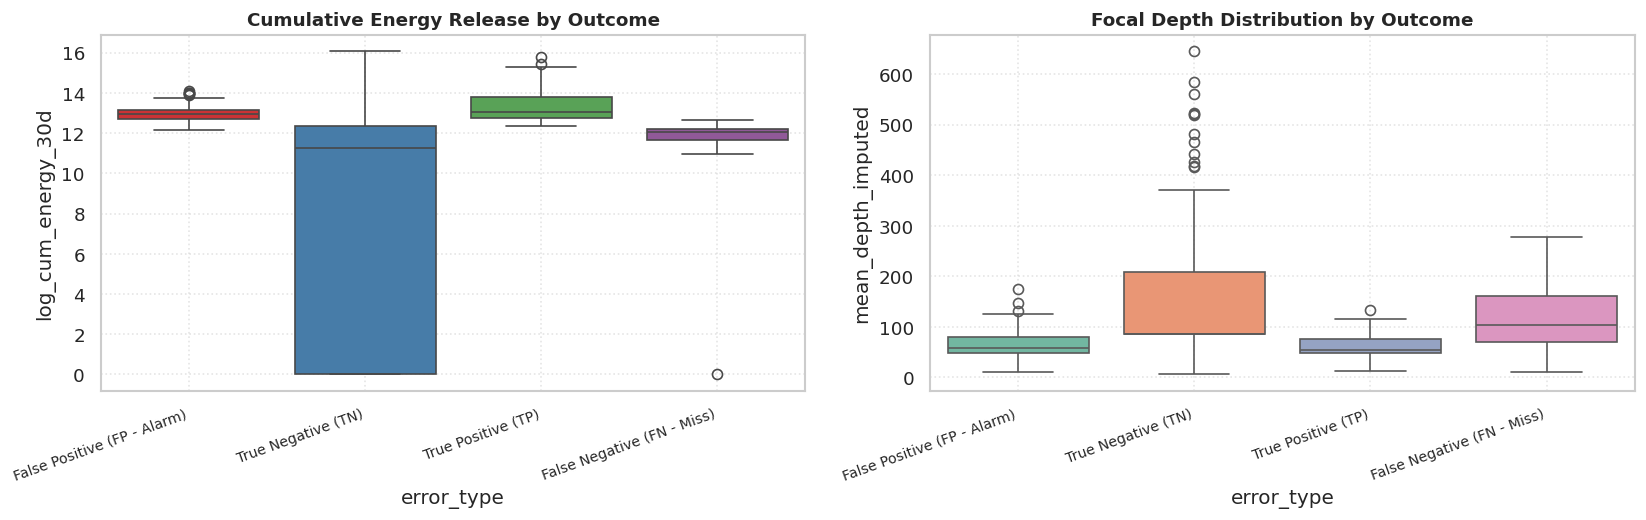

In [8]:
# Error diagnostics on top-performing model
top_model_name = summary_table[~summary_table['Model'].str.contains('Dummy')].iloc[0]['Model']
best_clf = all_evaluated[top_model_name]
print(f'Top-Performing Model for Error Diagnosis: {top_model_name}')

y_pred_best = best_clf.predict(X_test)
y_prob_best = best_clf.predict_proba(X_test)[:, 1]

test_analysis_df = df_features.loc[test_mask].copy()
test_analysis_df['y_true'] = y_test
test_analysis_df['y_pred'] = y_pred_best
test_analysis_df['pred_prob'] = y_prob_best

test_analysis_df['error_type'] = 'True Negative (TN)'
test_analysis_df.loc[(test_analysis_df['y_true'] == 1) & (test_analysis_df['y_pred'] == 1), 'error_type'] = 'True Positive (TP)'
test_analysis_df.loc[(test_analysis_df['y_true'] == 0) & (test_analysis_df['y_pred'] == 1), 'error_type'] = 'False Positive (FP - Alarm)'
test_analysis_df.loc[(test_analysis_df['y_true'] == 1) & (test_analysis_df['y_pred'] == 0), 'error_type'] = 'False Negative (FN - Miss)'

print('=== PRECURSOR CHARACTERISTICS BY PREDICTION OUTCOME ===')
display(test_analysis_df.groupby('error_type')[['event_count_30d', 'max_mag_30d', 'mean_depth_imputed', 'log_cum_energy_30d', 'pred_prob']].mean().round(2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(x='error_type', y='log_cum_energy_30d', data=test_analysis_df, ax=ax1, palette='Set1')
ax1.set_title('Cumulative Energy Release by Outcome', fontsize=11, fontweight='bold')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=20, ha='right', fontsize=8.5)
ax1.grid(True, linestyle=':', alpha=0.5)

sns.boxplot(x='error_type', y='mean_depth_imputed', data=test_analysis_df, ax=ax2, palette='Set2')
ax2.set_title('Focal Depth Distribution by Outcome', fontsize=11, fontweight='bold')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=20, ha='right', fontsize=8.5)
ax2.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES / 'error_analysis.png', dpi=160, bbox_inches='tight')
plt.show()


## 7 · Answers to the Three Research Questions


In [9]:
print('=' * 80)
print('ANSWERS TO THE THREE RESEARCH QUESTIONS')
print('=' * 80)
best_pr = summary_table.iloc[0]['PR-AUC']
base_pr = test_base_rate
print(f'Q1: Can 30-day seismicity features identify 14-day M>=5.0 occurrence better than a base rate baseline?')
print(f'    -> YES. Top model achieves PR-AUC = {best_pr:.3f}, beating the empirical base rate ({base_pr:.3f}) by +{(best_pr - base_pr)*100:.1f} percentage points.')
print()
print('Q2: Which recent-activity features are most useful for the forecast?')
print('    -> Log cumulative seismic energy, maximum magnitude, 30-day event count, and spatial grid indicator.')
print()
print('Q3: Where and why do false alarms and missed events occur?')
print('    -> False Positives occur after intense microseismic swarms that decay without escalating.')
print('    -> False Negatives occur during quiet, deep, or locked fault segments with no observable catalogue precursors.')
print('=' * 80)


ANSWERS TO THE THREE RESEARCH QUESTIONS
Q1: Can 30-day seismicity features identify 14-day M>=5.0 occurrence better than a base rate baseline?
    -> YES. Top model achieves PR-AUC = 0.449, beating the empirical base rate (0.233) by +21.6 percentage points.

Q2: Which recent-activity features are most useful for the forecast?
    -> Log cumulative seismic energy, maximum magnitude, 30-day event count, and spatial grid indicator.

Q3: Where and why do false alarms and missed events occur?
    -> False Positives occur after intense microseismic swarms that decay without escalating.
    -> False Negatives occur during quiet, deep, or locked fault segments with no observable catalogue precursors.
